# **Exercise 1 : Small Quizz**

1. What is the key difference between traditional machine learning and deep learning?

The main difference is that traditional machine learning requires humans to manually define or extract features for the model, while deep learning automatically learns patterns and representations directly from raw data.

⸻

2. How do artificial neural networks (ANNs) mimic the human brain?

ANNs mimic the human brain by using artificial “neurons” that receive input, process it, and pass it to other connected neurons — just like how the brain’s neurons transmit signals to make decisions or recognize patterns.

⸻

3. Why does deep learning perform better on large datasets compared to traditional machine learning?

Deep learning models have millions of parameters that allow them to capture very complex patterns in data. However, they need large amounts of data to learn effectively and avoid overfitting (memorizing instead of generalizing).

⸻

4. What are some challenges of deep learning, and how can they be addressed?

Deep learning models require massive datasets, powerful GPUs, and can easily overfit.
These challenges can be managed using techniques like data augmentation, transfer learning, dropout, and regularization, or by using cloud-based GPU computing to handle large workloads.

⸻

5. What is feature engineering, and why is it not needed in deep learning?

Feature engineering means manually selecting or designing the most useful features for the model. Deep learning, however, automatically learns features and representations from raw data, so human-designed features are not always needed.

⸻

6. What role do hidden layers play in a deep learning model?

Hidden layers are where learning happens — each layer gradually transforms the input into more abstract and meaningful patterns. For example, in image recognition, early layers might detect edges, while deeper layers recognize objects like faces or cars.

⸻

7. In an artificial neural network (ANN), what is the function of an activation function?

The activation function decides whether a neuron should be activated or not. It helps the network capture complex, non-linear relationships in data instead of just simple straight-line patterns.



# **Exercise 2 : Building a Simple Perceptron Decision System**

In [9]:
# Formula
# Weighted Sum=(Temperature×0.6)+(Rain×0.4)+Bias

# Conditions
# Case 1: Temperature = 70°F, Rain = 0 (No)
# Case 2: Temperature = 50°F, Rain = 1 (Yes)

# Assigned weight
temperature_weight = 0.6
rain_weight = 0.4
bias = 2

# Case 1
weighted_sum_case1 = (70 * temperature_weight) + (0 * rain_weight) + bias

# Applying step activation function
if weighted_sum_case1 > 20:
  print("Yes, go outside")
if weighted_sum_case1 <= 20:
  print("No, stay inside")

# Case 2
weighted_sum_case2 = (50 * temperature_weight) + (1 * rain_weight) + bias

# Applying step activation function
if weighted_sum_case2 > 20:
  print("Yes, go outside")
if weighted_sum_case2 <= 20:
  print("No, stay inside")

Yes, go outside
Yes, go outside


Interpret the results: Did the perceptron suggest going outside in both cases? Why or why not?

- The perceptron suggests going outside in both cases because the weighted sum is greater than 20.
- Why? We can see that the temperature weight had a great influence on the suggested output.

# **Exercise 3 : Building a Simple Neural Network with TensorFlow/Keras**

In [21]:
# Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# To remove randomness
tf.random.set_seed(42)
np.random.seed(42)

# Loaing the MNIST dataset
# side note: x_** are images of shap, y_** are labels
(X_train, y_train), (X_test,  y_test) = mnist.load_data()

# Normalising
X_train = X_train.astype("float32") / 255.0
Y_train = y_train.astype("float32") / 255.0

# One-hot encoding labels
num_classes = 10
y_train_oh = to_categorical(y_train, num_classes)
y_test_oh = to_categorical(y_test, num_classes)

# Building the model
model = models.Sequential([
   layers.Flatten(input_shape=(28,28)), # Input layer
   layers.Dense(128,activation="relu"), # Hidden layer
   layers.Dense(num_classes, activation="softmax") # Output layer
])


# Compiling the model
# - 'adam' is the default optimizer
# - 'categorical_crossentropy' for multi-class classification with one-hot labels
# - tracking 'accuracy' to see how well we’re doing
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Training the model
history = model.fit(
    X_train, y_train_oh,
    epochs=5,                # you can increase for better accuracy
    batch_size=128,          # how many images to work with then updating step
    validation_split=0.1     # keeping 10% of training data to monitor validation performance
)

# Evaluting on the test set
test_loss, test_acc = model.evaluate(X_test, y_test_oh, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Making a quick prediction demo (first 5 test images)
pred_probs = model.predict(X_test[:5], verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)
print("True labels:     ", y_test[:5])
print("Predicted labels:", pred_labels)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8211 - loss: 0.6479 - val_accuracy: 0.9533 - val_loss: 0.1740
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9441 - loss: 0.1958 - val_accuracy: 0.9658 - val_loss: 0.1285
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9609 - loss: 0.1374 - val_accuracy: 0.9682 - val_loss: 0.1088
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9699 - loss: 0.1052 - val_accuracy: 0.9718 - val_loss: 0.0979
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9767 - loss: 0.0839 - val_accuracy: 0.9735 - val_loss: 0.0908

Test Accuracy: 0.9703
True labels:      [7 2 1 0 4]
Predicted labels: [7 2 1 0 4]


# **Exercise 4 : Forward Propagation Calculation**

In [23]:
# z =(Square Footage×0.6)+(Number of Bedrooms×0.4)+Bias


# Calculation for output value "z"
z = (2000 * 0.5) + (3 * 0.7) + 50000

# Applying ReLU function
import numpy as np

output = np.maximum(0, z)
print(output)

51002.1


# **Exercise 5(optional) : Implementing Forward and Backward Propagation in Python**

In [24]:
# Initialize input data (features)
x = np.array([4, 80])  # 4 hours studied, previous test score: 80

# Initialize weights and bias
w = np.array([0.6, 0.3])  # Initial weights
b = 10  # Initial bias

# Forward Propagation
def forward_propagation(x, w, b):
    z = np.dot(x, w) + b  # Weighted sum
    return z  # Linear activation (No ReLU here, it's a regression task)

# Compute prediction
y_pred = forward_propagation(x, w, b)
y_true = 85  # Actual exam score

# Compute Loss (Mean Squared Error)
loss = 0.5 * (y_true - y_pred) ** 2

# Compute Gradients
grad_w = -(y_true - y_pred) * x  # Partial derivatives with respect to weights
grad_b = -(y_true - y_pred)  # Partial derivative with respect to bias

# Update Weights and Bias
learning_rate = 0.01
w_new = w - learning_rate * grad_w
b_new = b - learning_rate * grad_b

# Print Results
print("Initial Prediction:", y_pred)
print("Loss:", loss)
print("Updated Weights:", w_new)
print("Updated Bias:", b_new)

Initial Prediction: 36.4
Loss: 1180.98
Updated Weights: [ 2.544 39.18 ]
Updated Bias: 10.486


# **Exercise 6(optional) : Visualizing Predictions on the MNIST Dataset**

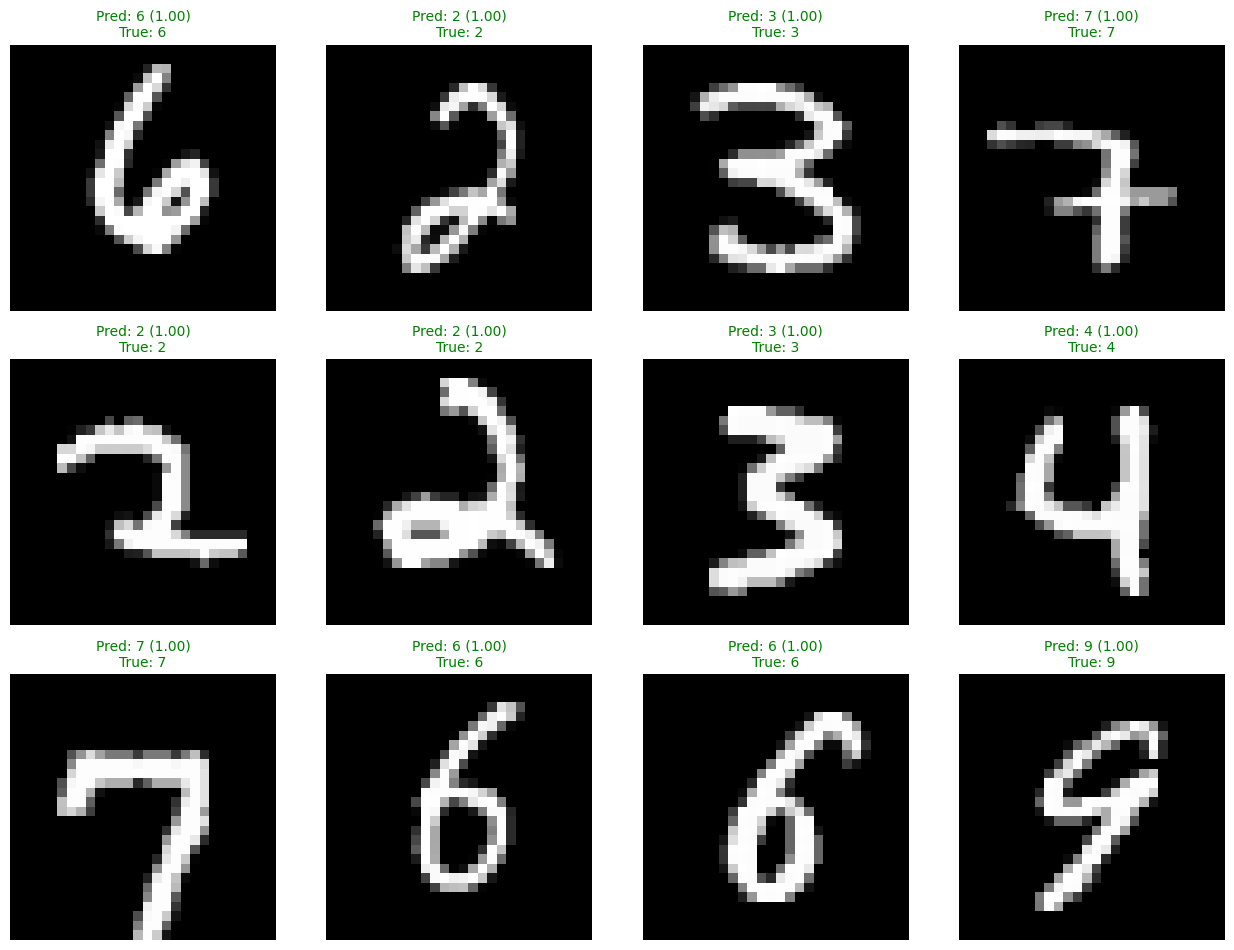

In [25]:
import matplotlib.pyplot as plt

# Get predicted probabilities and labels for the whole test set
probs = model.predict(X_test, verbose=0)              # shape (10000, 10)
y_pred = np.argmax(probs, axis=1)                     # predicted class per image
y_true = y_test                                       # integer labels (not one-hot)

# Helper: plot N random test images with predictions
def plot_preds(X, y_true, y_pred, probs, n=12, seed=42):
    np.random.seed(seed)
    idx = np.random.choice(len(X), size=n, replace=False)

    cols = 4
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3.2*cols, 3.2*rows))

    for i, j in enumerate(idx, start=1):
        plt.subplot(rows, cols, i)
        # MNIST images are 28x28; if channel axis present, squeeze it
        img = X[j]
        if img.ndim == 3:
            img = img.squeeze()
        plt.imshow(img, cmap="gray")
        pred = y_pred[j]
        true = y_true[j]
        conf = probs[j, pred]  # confidence for the predicted class
        ok = (pred == true)
        title_color = "green" if ok else "red"
        plt.title(f"Pred: {pred} ({conf:.2f})\nTrue: {true}", color=title_color, fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_preds(X_test, y_true, y_pred, probs, n=12)